<div style="border-bottom: 4px solid #003366; margin-bottom: 20px; padding-bottom: 10px; display: flex; justify-content: space-between; align-items: center;">
    <div style="flex-grow: 1;">
        <h1 style="color: #003366; font-family: 'Helvetica', sans-serif; margin-bottom: 5px;">MAT1610: Cálculo I</h1>
        <h2 style="color: #555; margin-top: 0; margin-bottom: 10px;">Laboratorio 02: El Concepto de Límite</h2>
        <p style="margin: 2px 0;"><b>Profesores:</b> XXX | <b>Fecha:</b> XX de XXX, 2026</p>
        <p style="margin: 2px 0;"><b>Institución:</b> Facultad de Matemáticas, Pontificia Universidad Católica de Chile</p>
    </div>
    <div style="flex: 0 0 auto; margin-left: 20px;">
        <img src="../source/FacMatematicas-15.png" 
             alt="Logo UC" 
             style="height: 60px; width: auto;">
    </div>
</div>

<div style="border: 1px solid #2980b9; border-left: 8px solid #2980b9; padding: 15px; border-radius: 5px; margin-bottom: 20px;">
    <h3 style="color: #2980b9; margin-top: 0;">Contexto y Referencias</h3>
    <p>Esta sesión explora el concepto de <b>límite</b> como la base fundamental que sustenta las ramas del cálculo diferencial e integral. Investigaremos cómo los valores de una función se comportan cerca de un punto, independientemente de si la función está definida en dicho valor.</p>
</div>

<div style="display: flex; gap: 20px;">
    <div style="flex: 1; border: 1px solid #27ae60; border-left: 8px solid #27ae60; padding: 15px; border-radius: 5px;">
        <h3 style="color: #27ae60; margin-top: 0;">Contenidos</h3>
        <ol>
            <li>Definición intuitiva de límite.</li>
            <li>Aproximación de límite.</li>
            <li>Límites laterales y detección de límites que no existen.</li>
        </ol>
    </div>
    <div style="flex: 1; border: 1px solid #f39c12; border-left: 8px solid #f39c12; padding: 15px; border-radius: 5px;">
        <h3 style="color: #f39c12; margin-top: 0;">Objetivos de Aprendizaje</h3>
        <ul>
            <li>Estimar límites evaluando funciones en puntos arbitrariamente cercanos a un valor crítico.</li>
            <li>Interpretar gráficamente el comportamiento de una función cerca de asíntotas y saltos.</li>
            <li>Identificar computacionalmente la diferencia entre el valor de una función y su límite.</li>
        </ul>
    </div>
</div>

In [6]:
import sympy as sp, numpy as np, matplotlib.pyplot as plt, pandas as pd
from ipywidgets import interact

# Configuración para renderizado de ecuaciones y gráficas
sp.init_printing(use_latex='mathjax')
%matplotlib inline

# Configuración de estilo robusta para las rejillas de las gráficas
try: plt.style.use('seaborn-v0_8-whitegrid')
except: plt.style.use('seaborn-whitegrid')
plt.rcParams['figure.figsize'] = (6, 4)

# **1. Definición Intuitiva de Límite**

El concepto de **límite** es la base que sustenta las distintas ramas del Cálculo. En términos generales, el límite investiga qué ocurre con los valores de una función $f(x)$ a medida que la entrada $x$ se acerca a un número $a$, sin llegar necesariamente a ser igual a $a$.

### **Notación de Límite**
Supongamos que $f(x)$ está definida cuando $x$ está cerca del número $a$. Escribimos:

$$\lim_{x \to a} f(x) = L$$

Esta expresión se lee como: **"el límite de $f(x)$, cuando $x$ tiende a $a$, es igual a $L$"**.

Decimos que el límite es $L$ si podemos hacer que los valores de $f(x)$ estén arbitrariamente cercanos a $L$ tomando valores de $x$ suficientemente cerca de $a$ (por ambos lados), **pero no iguales a $a$**. Es fundamental notar que el valor de $f(a)$ no es relevante; el límite existe incluso si la función no está definida en dicho punto.

--------------------------------------------------------------------------------

# **2. Aproximación**


Para entender el concepto de **límite**, primero debemos observar cómo se comporta una función cerca de un valor específico, incluso si la función no está definida en ese punto.

Consideremos la función:
$$f(x) = \frac{x^2 - 1}{x - 1}$$

### Tabla de valores
Si intentamos evaluar $f(1)$, obtenemos una indeterminación ($0/0$). Sin embargo, podemos usar una **tabla de valores** para ver hacia dónde "tiende" la función a medida que $x$ se acerca a 1 por la izquierda (valores menores) y por la derecha (valores mayores).



In [7]:
# Definición de la función racional
def f(x): 
    return (x**2 - 1) / (x - 1)

In [40]:
# Valores acercándose a 1 por ambos lados
puntos_izq = [0.5, 0.9, 0.95, 0.99, 0.95 , 0.999]
puntos_der = [1.5, 1.1, 1.05, 1.01, 1.005, 1.001]

# Crear tabla comparativa
df = pd.DataFrame({
    'x (Izq)': puntos_izq, 'f(x) Izq': f(np.array(puntos_izq)),
    'x (Der)': puntos_der, 'f(x) Der': f(np.array(puntos_der))
})

print("Comportamiento de f(x) cerca de x = 1:")
df.round(4)

Comportamiento de f(x) cerca de x = 1:


,x (Izq),f(x) Izq,x (Der),f(x) Der
0,0.500,1.500,1.500,2.500
1,0.900,1.900,1.100,2.100
2,0.950,1.950,1.050,2.050
3,0.990,1.990,1.010,2.010
4,0.950,1.950,1.005,2.005
5,0.999,1.999,1.001,2.001


### **Representación Visual (Zoom)**

Aunque las tablas numéricas sugieren la existencia de un límite, la gráfica de la función nos permite confirmar este comportamiento de forma intuitiva. 

Al graficar $$f(x) = \frac{x^2 - 1}{x - 1}$$ observaremos que en $x = 1$ no podemos evaluar, la curva parece dirigirse sin interrupciones hacia un valor específico de altura ($y$). En Cálculo, decimos que el límite es $L$ si los valores de salida se aproximan a $L$ a medida que $x$ se acerca a $a$ por cualquier lado.

Usa el control deslizante a continuación para realizar un **acercamiento (zoom in)** al punto crítico y observa hacia qué valor de $y$ converge la función.


In [42]:
@interact(zoom=(1, 50, 1))
def graficar_limite(zoom=1):
    # Definir un rango que se reduce según el zoom
    ancho = 2 / zoom
    x = np.linspace(1 - ancho, 1 + ancho, 500)
    x = x[x != 1] # Filtramos el 1 para evitar el error de división por cero
    
    plt.plot(x, f(x), color='blue', lw=2, label='$f(x)$')
    
    # Dibujar el punto (1, 2) donde no se evalua f
    plt.plot(1, 2, 'ro', fillstyle='none', markersize=10, label='$f(1)$ no definido')
    
    plt.title(f"Acercamiento al punto crítico (Zoom: {zoom}x)")
    plt.xlabel("x"); plt.ylabel("f(x)")
    plt.axhline(2, color='gray', ls='--', alpha=0.5) # Línea guía en L=2
    plt.legend(); plt.show()


interactive(children=(IntSlider(value=1, description='zoom', max=50, min=1), Output()), _dom_classes=('widget-…

# **3. Límites Laterales**

En ocasiones, una función se aproxima a valores distintos dependiendo de si nos acercamos al punto $a$ por la izquierda (valores menores que $a$) o por la derecha (valores mayores que $a$).

*   **Límite por la izquierda:** Se denota como $\lim_{x \to a^-} f(x) = L$. Significa que $f(x)$ se acerca a $L$ conforme $x$ se acerca a $a$ con valores $x < a$ [3].
*   **Límite por la derecha:** Se denota como $\lim_{x \to a^+} f(x) = L$. Significa que $f(x)$ se acerca a $L$ conforme $x$ se acerca a $a$ con valores $x > a$ [4].

**Criterio de existencia:** El límite general $\lim_{x \to a} f(x)$ existe si y solo si ambos límites laterales existen y son iguales:
$$\lim_{x \to a^-} f(x) = \lim_{x \to a^+} f(x) = L$$

### **Aproximación Numérica de Límites Laterales**

Para una función definida por partes, el límite general existe solo si los límites por la izquierda ($x \to a^-$) y por la derecha ($x \to a^+$) coinciden. Utilizaremos la siguiente función para explorar el comportamiento en el punto de cambio $x = 1$:

$$f(x) = \begin{cases} 1 - x & \text{si } x \le 1 \\ x^2 & \text{si } x > 1 \end{cases}$$

Evaluaremos valores muy cercanos a $1$ para observar si la función tiende al mismo número desde ambas direcciones.


In [23]:
# 1. Definición de la función por partes (no constante)
def f_partes(x):
    # Regla: 1-x para x <= 1; x^2 para x > 1
    return np.piecewise(x, [x <= 1, x > 1], [lambda x: 1 - x, lambda x: x**2])

# 2. Configuración del punto crítico y acercamientos (h)
a = 1
h = np.array([0.1, 0.01, 0.001, 0.0001])

# 3. Cálculo de puntos por izquierda y derecha
x_izq = a - h
x_der = a + h

# 4. Creación de la tabla comparativa
tabla_lateral = pd.DataFrame({
    'x (Hacia 1-)': x_izq,
    'f(x) Izquierda': f_partes(x_izq),
    'x (Hacia 1+)': x_der,
    'f(x) Derecha': f_partes(x_der)
})

print("Evaluación de límites laterales en x = 1:")
tabla_lateral.round(6)

Evaluación de límites laterales en x = 1:


,x (Hacia 1-),f(x) Izquierda,x (Hacia 1+),f(x) Derecha
0,0.9000,0.1000,1.1000,1.210000
1,0.9900,0.0100,1.0100,1.020100
2,0.9990,0.0010,1.0010,1.002001
3,0.9999,0.0001,1.0001,1.000200


### Ejemplo
$$
\lim_{x\to 0} x\sin(1/x)
$$

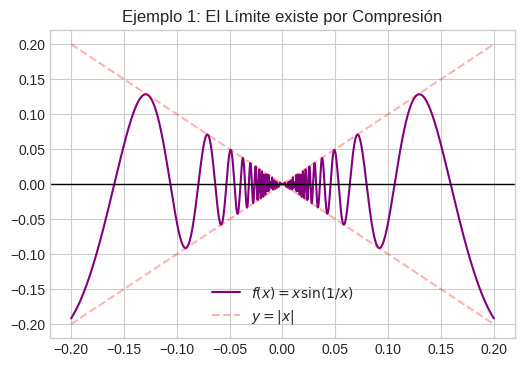

In [24]:
def f1(x): return x * np.sin(1/x)

x = np.linspace(-0.2, 0.2, 1000)
x = x[x != 0]

plt.plot(x, f1(x), label='$f(x) = x \sin(1/x)$', color='purple')
# Líneas de "apretón" (Teorema de la Compresión)
plt.plot(x, np.abs(x), 'r--', alpha=0.3, label='$y = |x|$')
plt.plot(x, -np.abs(x), 'r--', alpha=0.3)

plt.title("Ejemplo 1: El Límite existe por Compresión")
plt.axhline(0, color='black', lw=1); plt.legend(); plt.show()

### Ejemplo
$$
\lim_{t\to 0}\frac{\sqrt{t^2 + 9} - 3)}{ t^2}
$$

In [43]:
def f3(t): return (np.sqrt(t**2 + 9) - 3) / t**2

@interact(t_eval=[0.1, 0.01, 0.001, 0.0001, 0.00001, 0.000001])
def evaluar_trampa(t_eval):
    valor = f3(t_eval)
    print(f"Para t = {t_eval}, f(t) ≈ {valor:.10f}")
    
    # Gráfica para confirmar visualmente el 1/6
    t_plot = np.linspace(-0.5, 0.5, 500)
    t_plot = t_plot[t_plot != 0]
    plt.plot(t_plot, f3(t_plot), color='orange')
    plt.axhline(1/6, color='red', ls=':', label='Límite Real = 1/6')
    plt.title("Ejemplo 3: Cuando la aritmética de la computadora falla")
    plt.legend(); plt.show()

interactive(children=(Dropdown(description='t_eval', options=(0.1, 0.01, 0.001, 0.0001, 1e-05, 1e-06), value=0…

### **Límites que no existen: El caso de la oscilación**

No todas las funciones se aproximan a un valor único. Un caso fascinante es cuando la función oscila con demasiada rapidez a medida que nos acercamos al punto crítico.

Consideremos la función:
$$f(x) = \sin\left(\frac{\pi}{x}\right)$$

A medida que $x \to 0$, el valor de $1/x$ se vuelve infinitamente grande, lo que causa que el seno oscile entre -1 y 1 infinitas veces en un intervalo cada vez más pequeño. Computacionalmente, esto puede engañar a las tablas de valores si no elegimos los puntos con cuidado.


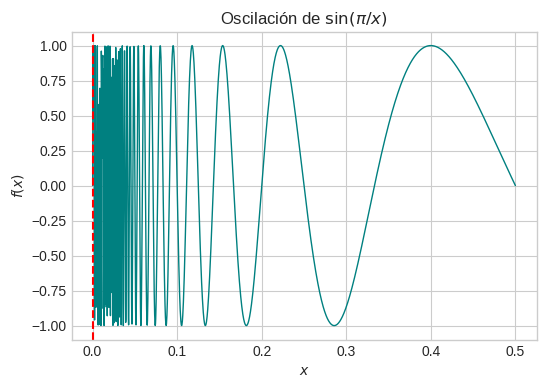

In [21]:
def f_osc(x): return np.sin(np.pi / x)

x = np.linspace(0.0001, 0.5, 2000)
plt.plot(x, f_osc(x), lw=1, color='teal')
plt.axvline(0, color='red', ls='--')
plt.title(r"Oscilación de $\sin(\pi/x)$")
plt.xlabel("$x$"); plt.ylabel("$f(x)$"); plt.show()

**Pregunta**

A continuación, responde la siguiente pregunta basada en tus observaciones previas. Selecciona una opción y presiona el botón para verificar tu respuesta.


In [18]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# Configuración de la pregunta
pregunta = widgets.RadioButtons(
    options=[
        ('El límite es 0', 1),
        ('El límite es 1', 2),
        ('El límite no existe por oscilación', 3),
        ('El límite es infinito', 4)
    ],
    description='¿Cuál es el límite de $\sin(\pi/x)$ cuando $x$ → $0$?',
    style={'description_width': 'initial'},
    layout={'width': 'max-content'}
)

boton = widgets.Button(description="Verificar", button_style='info')
salida = widgets.Output()

def verificar(b):
    with salida:
        clear_output()
        if pregunta.value == 3:
            print("✅ ¡Correcto! La función nunca se estabiliza en un valor único.")
        else:
            print("❌ Incorrecto. Observa la gráfica de nuevo: la función salta entre -1 y 1 sin parar.")

boton.on_click(verificar)
display(pregunta, boton, salida)

RadioButtons(description='¿Cuál es el límite de $\\sin(\\pi/x)$ cuando $x$ → $0$?', layout=Layout(width='max-c…

Button(button_style='info', description='Verificar', style=ButtonStyle())

Output()

# **4. Límites Infinitos y limite al infinito**

Decimos que un límite es **infinito** cuando los valores de $f(x)$ crecen sin cota a medida que $x$ se acerca a $a$. Simbólicamente:
$$\lim_{x \to a} f(x) = \infty$$

Es importante recordar que $\infty$ no es un número; esta notación simplemente describe un comportamiento específico: la función aumenta arbitrariamente cerca del punto. 

**Definición de Asíntota Vertical:**
La recta $x = a$ se llama asíntota vertical de la curva $y = f(x)$ si el límite (o alguno de los límites laterales) en ese punto es infinito ($\infty$ o $-\infty$).


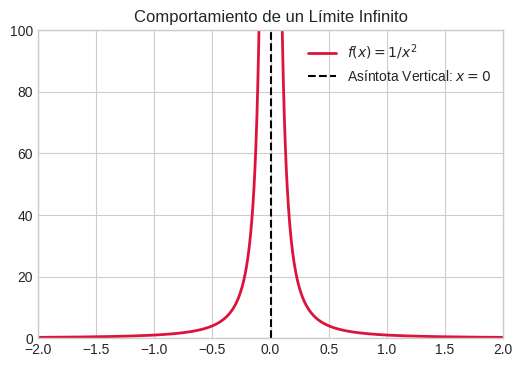

In [26]:
def f_inf(x): return 1 / x**2

x = np.linspace(-2, 2, 1000)
x = x[x != 0] # Evitar división por cero

plt.plot(x, f_inf(x), color='crimson', lw=2, label='$f(x) = 1/x^2$')
plt.axvline(0, color='black', ls='--', label='Asíntota Vertical: $x=0$')

plt.ylim(0, 100); plt.xlim(-2, 2)
plt.title("Comportamiento de un Límite Infinito")
plt.legend(); plt.show()

### **Límites al Infinito y Asíntotas Horizontales**

En esta sección investigamos qué ocurre con $f(x)$ cuando la variable independiente crese sin límite ($x \to \infty$) o decrece sin límite ($x \to -\infty$).

Si los valores de $f(x)$ se aproximan a un número real $L$ cuando $x$ es suficientemente grande, decimos que:
$$\lim_{x \to \infty} f(x) = L$$

En este caso, la recta **$y = L$** se denomina **asíntota horizontal** de la curva. Este concepto es clave para entender el comportamiento de "largo plazo" de los modelos matemáticos.


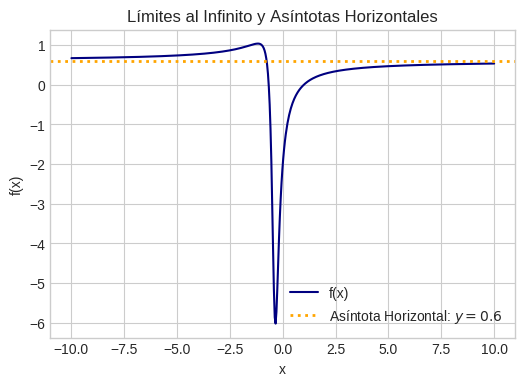

In [27]:
def f_racional(x): 
    return (3*x**2 - x - 2) / (5*x**2 + 4*x + 1)

x = np.linspace(-10, 10, 500)
plt.plot(x, f_racional(x), color='navy', label='f(x)')

# Dibujar Asíntota Horizontal en y = 3/5
plt.axhline(3/5, color='orange', ls=':', lw=2, label='Asíntota Horizontal: $y=0.6$')

plt.title("Límites al Infinito y Asíntotas Horizontales")
plt.xlabel("x"); plt.ylabel("f(x)")
plt.legend(); plt.show()

# **7. Ejercicio Integrador: Análisis Global de Límites**

Para poner a prueba todo lo aprendido, analizaremos la siguiente función "híbrida":

$$f(x) = \begin{cases} e^x & \text{si } x < 0 \\ \frac{1}{x} + 2 & \text{si } x > 0 \end{cases}$$

Este modelo presenta diversos escenarios críticos que investigaremos numérica y gráficamente:
1.  **Límite por la izquierda en $x=0$:** ¿Hacia qué valor finito tiende la parte exponencial? [Stewart, pág. 120].
2.  **Límite por la derecha en $x=0$:** ¿Cómo se comporta la parte racional cerca de su asíntota? [Stewart, pág. 175].
3.  **Comportamiento en el infinito negativo ($x \to -\infty$):** ¿Tiene una asíntota horizontal a la izquierda? [Stewart, pág. 311].
4.  **Comportamiento en el infinito positivo ($x \to \infty$):** ¿Hacia dónde se estabiliza la función a largo plazo? [Stewart, pág. 303].


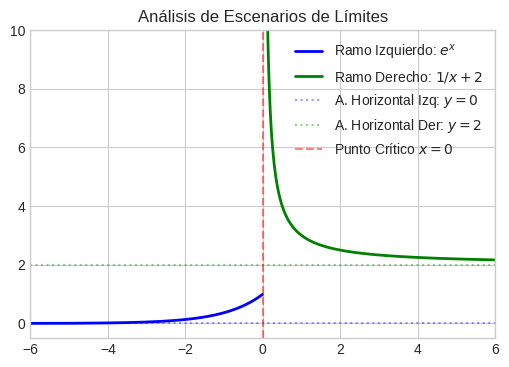

In [29]:
def f_final(x):
    # Definimos la función usando las reglas de Stewart para funciones por partes
    return np.piecewise(x, [x < 0, x > 0], [lambda x: np.exp(x), lambda x: (1/x) + 2])

x_neg = np.linspace(-10, -0.01, 500)
x_pos = np.linspace(0.01, 10, 500)

plt.figure()
plt.plot(x_neg, f_final(x_neg), 'b', lw=2, label='Ramo Izquierdo: $e^x$')
plt.plot(x_pos, f_final(x_pos), 'g', lw=2, label='Ramo Derecho: $1/x + 2$')

# Ilustración de límites y asíntotas
plt.axhline(0, color='blue', ls=':', alpha=0.4, label='A. Horizontal Izq: $y=0$')
plt.axhline(2, color='green', ls=':', alpha=0.4, label='A. Horizontal Der: $y=2$')
plt.axvline(0, color='red', ls='--', alpha=0.5, label='Punto Crítico $x=0$')

plt.ylim(-0.5, 10); plt.xlim(-6, 6)
plt.title("Análisis de Escenarios de Límites")
plt.legend(); plt.show()

In [32]:
# Cell Tag: hide-input
pregunta_final = widgets.RadioButtons(
    options=[
        ('$\lim_{x \\to 0^-} f(x) = 1$ y $\lim_{x \\to \\infty} f(x) = 2$', 1),
        ('$\lim_{x \\to 0^+} f(x) = 2$ y $\lim_{x \\to -\\infty} f(x) = 1$', 2),
        ('El límite general en 0 existe y es $\infty$', 3),
        ('No hay asíntotas horizontales en esta función', 4)
    ],
    description='Basado en la gráfica, ¿cuál de estas afirmaciones es correcta?',
    style={'description_width': 'initial'},
    layout={'width': 'max-content'}
)

boton_fin = widgets.Button(description="Finalizar Lab", button_style='primary')
salida_fin = widgets.Output()

def verificar_final(b):
    with salida_fin:
        clear_output()
        if pregunta_final.value == 1:
            print("✅ ¡Excelente conclusión! Has identificado correctamente:")
            print("   1. El límite finito por la izquierda (1).")
            print("   2. El límite infinito por la derecha (∞).")
            print("   3. La asíntota horizontal en y=2 para x muy grande.")
        else:
            print("❌ Revisa los extremos de la gráfica y el comportamiento cerca de x=0.")

boton_fin.on_click(verificar_final)
display(pregunta_final, boton_fin, salida_fin)

RadioButtons(description='Basado en la gráfica, ¿cuál de estas afirmaciones es correcta?', layout=Layout(width…

Button(button_style='primary', description='Finalizar Lab', style=ButtonStyle())

Output()

### **Ejemplo 4: El Límite de $(\cos(x) - 1) / x$**

Este es otro límite crucial para el cálculo de derivadas de funciones trigonométricas. A diferencia de $\frac{\sin(x)}{x}$, donde los valores se estabilizan en 1, aquí observaremos cómo la función se aproxima a cero.

Visualmente, esto significa que la curva "atraviesa" el origen con una pendiente horizontal, a pesar de que la función no está definida exactamente en $x = 0$.


Aproximación numérica cerca de 0:


,x,f(x)
4,-0.1000,0.049958
5,-0.0100,0.005000
6,-0.0010,0.000500
7,-0.0001,0.000050
3,0.0001,-0.000050
2,0.0010,-0.000500
1,0.0100,-0.005000
0,0.1000,-0.049958


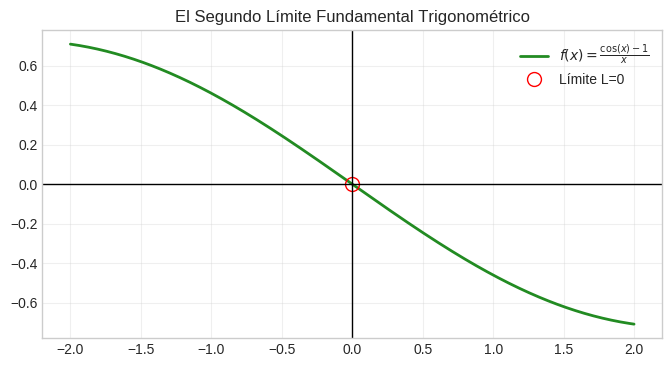

In [35]:
def f_cos(x): return (np.cos(x) - 1) / x

# 1. Evidencia Numérica
x_vals = np.array([0.1, 0.01, 0.001, 0.0001, -0.1, -0.01, -0.001, -0.0001])
df_cos = pd.DataFrame({'x': x_vals, 'f(x)': f_cos(x_vals)})
print("Aproximación numérica cerca de 0:")
display(df_cos.sort_values(by='x'))

# 2. Representación Visual
x_plot = np.linspace(-2, 2, 500)
x_plot = x_plot[x_plot != 0]

plt.figure(figsize=(8, 4))
plt.plot(x_plot, f_cos(x_plot), label=r'$f(x) = \frac{\cos(x)-1}{x}$', color='forestgreen', lw=2)
plt.plot(0, 0, 'ro', fillstyle='none', markersize=10, label='Límite L=0')

plt.title("El Segundo Límite Fundamental Trigonométrico")
plt.axhline(0, color='black', lw=1); plt.axvline(0, color='black', lw=1)
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

# **8. Cálculo Simbólico: Resultados Exactos**

Hasta este punto, hemos explorado los límites de forma **numérica** (evaluando puntos cercanos) y **visual** (observando gráficas). Sin embargo, estos métodos tienen limitaciones, como los errores de precisión en la computadora o la dificultad de interpretar oscilaciones rápidas [1].

### **¿Qué es el Cálculo Simbólico?**
A diferencia del cálculo numérico, que opera con aproximaciones decimales, el **cálculo simbólico** manipula expresiones matemáticas como objetos algebraicos puros. Esto permite obtener resultados exactos, manteniendo símbolos como $\pi$, $e$ o $\sqrt{2}$ sin redondearlos.

### **Cálculo Simbólico en Python con SymPy**
Para realizar esto en Python, utilizamos la librería **SymPy** [3]. Esta herramienta permite definir variables como **símbolos** en lugar de simples contenedores de números. Con SymPy, el software no "estima" el límite probando valores; en su lugar, utiliza reglas algebraicas y teoremas matemáticos sofisticados para encontrar el valor exacto, evitando así las "trampas numéricas" que vimos anteriormente [1, 2].


In [39]:
# 1. Definimos el símbolo y la expresión
x = sp.Symbol('x')
expr = (sp.cos(x) - 1) / x

# 2. Creamos el objeto del límite (sin evaluarlo aún) para mostrarlo
limite_visual = sp.Limit(expr, x, 0, dir='+-')

print("El problema propuesto es:")
display(limite_visual) # Muestra el límite con notación LaTeX [1]

# 3. Calculamos el resultado
resultado = limite_visual.doit()

print("La solución exacta calculada por SymPy es:")
display(resultado)

El problema propuesto es:


    ⎛cos(x) - 1⎞
lim ⎜──────────⎟
x─→0⎝    x     ⎠

La solución exacta calculada por SymPy es:


0

<div class="alert alert-block alert-success" style="background-color: #e8f5e9; border-left: 5px solid #4caf50; padding: 15px; border-radius: 5px;"> 
    <h2 style="color: #2e7d32; margin-top: 0;">🏁 Ticket de Salida</h2>
    <p style="font-size: 1.1em; color: #1b5e20;"><strong>¡Felicidades!</strong> Hemos llegado al final de los contenidos de este laboratorio. Ahora es tu turno de poner en práctica lo que aprendiste resolviendo los siguientes retos computacionales.</p>
    <h3 style="color: #2e7d32; margin-top: 15px;">💻 Ejercicios: </h3>
</div>


<div style="width: 100%; border-top: 2px solid #ddd; padding-top: 15px; margin-top: 30px; font-family: sans-serif; font-size: 0.85em; color: #666;">
    <p>
        <strong>© 2026 Manuel A. Sánchez </strong><br>
        <a href="https://www.mat.uc.cl/" style="color: #003366; text-decoration: none;">Facultad de Matemáticas</a><br>
        Pontificia Universidad Católica de Chile
    </p>
    <p>
        <i>Este material está diseñado para el curso MAT1610 y no debe ser redistribuido sin permiso explícito.</i>
    </p>
</div>